<a href="https://www.kaggle.com/code/maximendacleu/llm-classification-finetuning?scriptVersionId=332746248" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# LLM Classification Finetuning (Chatbot Arena EDA)

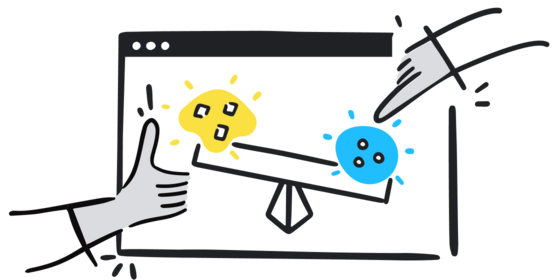

This notebook explores the Chatbot Arena dataset for the Kaggle competition. The goal here is to predict which chatbot response users will prefer in a head-to-head comparison. The analysis covers data structure, model and label distributions, and text-length characteristics.

## 1. Load data and understand file structure

We first load available CSV files and inspect the shape, columns, and example rows. This clearly defines the task and the available information for modeling.

In [10]:
import ast
import json
from pathlib import Path
import pandas as pd
from IPython.display import display, HTML
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import make_pipeline
from sklearn.metrics import log_loss

DATA_DIR = Path('.')
train = pd.read_csv('/kaggle/input/competitions/llm-classification-finetuning/train.csv')
test = pd.read_csv('/kaggle/input/competitions/llm-classification-finetuning/test.csv')

display(HTML('<h3>Loaded datasets</h3>'))
display(pd.DataFrame([
    {'filename': 'train.csv', 'shape': train.shape, 'columns': list(train.columns)},
    {'filename': 'test.csv', 'shape': test.shape, 'columns': list(test.columns)},
]))

,filename,shape,columns
0,train.csv,"(57477, 9)","[id, model_a, model_b, prompt, response_a, res..."
1,test.csv,"(3, 4)","[id, prompt, response_a, response_b]"


In [11]:
display(HTML('<h3>Sample training rows</h3>'))
display(train.head(3))

display(HTML('<h3>Sample test rows</h3>'))
display(test.head(3))

,id,model_a,model_b,prompt,response_a,response_b,winner_model_a,winner_model_b,winner_tie
0,30192,gpt-4-1106-preview,gpt-4-0613,"[""Is it morally right to try to have a certain...","[""The question of whether it is morally right ...","[""As an AI, I don't have personal beliefs or o...",1,0,0
1,53567,koala-13b,gpt-4-0613,"[""What is the difference between marriage lice...","[""A marriage license is a legal document that ...","[""A marriage license and a marriage certificat...",0,1,0
2,65089,gpt-3.5-turbo-0613,mistral-medium,"[""explain function calling. how would you call...","[""Function calling is the process of invoking ...","[""Function calling is the process of invoking ...",0,0,1


,id,prompt,response_a,response_b
0,136060,"[""I have three oranges today, I ate an orange ...","[""You have two oranges today.""]","[""You still have three oranges. Eating an oran..."
1,211333,"[""You are a mediator in a heated political deb...","[""Thank you for sharing the details of the sit...","[""Mr Reddy and Ms Blue both have valid points ..."
2,1233961,"[""How to initialize the classification head wh...","[""When you want to initialize the classificati...","[""To initialize the classification head when p..."


### What we know from the files

- `train.csv` contains chat prompts, two candidate responses, the names of the two models, and three winner columns.
- `test.csv` provides the same prompt and response pair format, but without winner labels.
- `sample_submission.csv` is a placeholder with equal probability values for `winner_model_a`, `winner_model_b`, and `winner_tie`.

The modeling task is a three-way preference classification: response A wins, response B wins, or the pair is tied.

## 2. Parse prompt and response content

The dataset stores the prompt and response fields as serialized lists of strings. We parse them into Python lists for richer analysis of prompt structure and response length.

In [12]:
def safe_parse_list(cell):
    if pd.isna(cell):
        return []
    if isinstance(cell, str):
        try:
            parsed = json.loads(cell)
            if isinstance(parsed, list):
                return [str(item) for item in parsed]
        except (json.JSONDecodeError, ValueError):
            pass
    try:
        parsed = ast.literal_eval(cell)
        if isinstance(parsed, list):
            return [str(item) for item in parsed]
    except (ValueError, SyntaxError):
        pass
    return [str(cell)]

train['prompt_list'] = train['prompt'].apply(safe_parse_list)
train['response_a_list'] = train['response_a'].apply(safe_parse_list)
train['response_b_list'] = train['response_b'].apply(safe_parse_list)

display(HTML('<h3>Parsed prompt/response shapes</h3>'))
display(pd.DataFrame({
    'prompt_items': train['prompt_list'].apply(len).head(5),
    'response_a_items': train['response_a_list'].apply(len).head(5),
    'response_b_items': train['response_b_list'].apply(len).head(5),
}))


,prompt_items,response_a_items,response_b_items
0,2,2,2
1,3,3,3
2,1,1,1
3,1,1,1
4,1,1,1


The parsed fields confirm that most prompts and responses are stored as lists. In this dataset, each entry generally contains: a prompt list with one or more user utterances, and one response list for each candidate reply.

## 3. Basic target and metadata analysis

We now inspect the label distribution and the LLM models involved in the training set. Understanding the balance of these classes is essential for selecting a robust modeling strategy.

In [13]:
train['winner'] = train[['winner_model_a', 'winner_model_b', 'winner_tie']].idxmax(axis=1)
train['winner'] = train['winner'].map({
    'winner_model_a': 'model_a',
    'winner_model_b': 'model_b',
    'winner_tie': 'tie'
})

winner_dist = train['winner'].value_counts(normalize=True).rename_axis('winner').reset_index(name='proportion')
model_a_count = train['model_a'].nunique()
model_b_count = train['model_b'].nunique()

display(HTML('<h3>Label distribution</h3>'))
display(winner_dist)
display(HTML('<h3>Model diversity</h3>'))
display(pd.DataFrame([{'field': 'model_a unique', 'count': model_a_count}, {'field': 'model_b unique', 'count': model_b_count}]))

top_model_a = train['model_a'].value_counts().head(10)
top_model_b = train['model_b'].value_counts().head(10)
display(HTML('<h3>Most frequent model names in each position</h3>'))
display(pd.DataFrame({
    'top_model_a': top_model_a.index.tolist(),
    'count_a': top_model_a.values.tolist(),
    'top_model_b': top_model_b.index.tolist(),
    'count_b': top_model_b.values.tolist(),
}))

,winner,proportion
0,model_a,0.349079
1,model_b,0.341911
2,tie,0.309011


,field,count
0,model_a unique,64
1,model_b unique,64


,top_model_a,count_a,top_model_b,count_b
0,gpt-4-1106-preview,3678,gpt-4-1106-preview,3709
1,gpt-3.5-turbo-0613,3553,gpt-3.5-turbo-0613,3530
2,gpt-4-0613,3099,gpt-4-0613,3066
3,claude-2.1,2859,claude-2.1,2724
4,gpt-4-0314,2087,claude-instant-1,2051
5,claude-instant-1,2085,gpt-4-0314,2035
6,claude-1,1955,claude-1,2023
7,vicuna-33b,1843,vicuna-33b,1877
8,mixtral-8x7b-instruct-v0.1,1741,mixtral-8x7b-instruct-v0.1,1804
9,mistral-medium,1706,llama-2-70b-chat,1753


### Interpretation

- The target is a three-class preference label: model A wins, model B wins, or a tie.
- A balanced winner distribution suggests that model performance differences are subtle and that a model should learn fine-grained preference signals.
- The number of unique model names in the dataset tells us that the problem is not just one head-to-head pair, but many possible model matchups. We need a solution that generalizes across different model pairs and user prompts.

## 4. Text-level feature analysis

We compute prompt and response lengths, and use them to identify simple patterns that may help guide model design.

In [14]:
if 'prompt_list' not in train.columns or 'response_a_list' not in train.columns or 'response_b_list' not in train.columns:
    train['prompt_list'] = train['prompt'].apply(safe_parse_list)
    train['response_a_list'] = train['response_a'].apply(safe_parse_list)
    train['response_b_list'] = train['response_b'].apply(safe_parse_list)

def safe_join_list_as_text(items):
    if not items:
        return ''
    return ' '.join(str(item) for item in items)

train['prompt_text'] = train['prompt_list'].apply(safe_join_list_as_text)
train['response_a_text'] = train['response_a_list'].apply(safe_join_list_as_text)
train['response_b_text'] = train['response_b_list'].apply(safe_join_list_as_text)
train['prompt_len'] = train['prompt_text'].str.len()
train['response_a_len'] = train['response_a_text'].str.len()
train['response_b_len'] = train['response_b_text'].str.len()
train['response_len_diff'] = train['response_a_len'] - train['response_b_len']
train['response_len_ratio'] = train['response_a_len'] / (train['response_b_len'].replace(0, 1))

summary_stats = train[['prompt_len', 'response_a_len', 'response_b_len', 'response_len_diff']].describe().T
display(HTML('<h3>Text length summary</h3>'))
display(summary_stats)

feature_by_winner = train.groupby('winner')[['prompt_len', 'response_a_len', 'response_b_len', 'response_len_diff']].mean().reset_index()
display(HTML('<h3>Average text lengths by winner category</h3>'))
display(feature_by_winner)


,count,mean,std,min,25%,50%,75%,max
prompt_len,57477.0,352.356612,1025.378233,3.0,48.0,91.0,233.0,32833.0
response_a_len,57477.0,1330.379839,1461.911619,0.0,391.0,1036.0,1810.0,53299.0
response_b_len,57477.0,1337.185483,1483.790795,0.0,395.0,1044.0,1819.0,52402.0
response_len_diff,57477.0,-6.805644,1060.944240,-51199.0,-413.0,0.0,405.0,42995.0


,winner,prompt_len,response_a_len,response_b_len,response_len_diff
0,model_a,348.645883,1515.413577,1266.446073,248.967504
1,model_b,341.204814,1246.256564,1515.719214,-269.462650
2,tie,368.887619,1214.433309,1219.555318,-5.122009


### Interpretation

- Prompt length and response lengths vary widely, which is expected for open-ended conversational questions.
- The difference between response lengths can reveal whether longer answers tend to win, or whether more concise responses are preferred.
- These simple text features are useful baseline signals, but the real predictive power will come from semantic quality and alignment to the prompt.

## 5. Model pair and winner structure

We inspect the most frequent matchups and how often ties occur relative to head-to-head wins. This reveals whether certain model pairs are consistently more contested.

In [15]:
train['pair'] = train['model_a'] + ' vs ' + train['model_b']
pair_counts = train['pair'].value_counts().head(15).rename_axis('pair').reset_index(name='count')
pair_wins = train.groupby(['pair', 'winner']).size().unstack(fill_value=0)
pair_wins['total'] = pair_wins.sum(axis=1)
pair_wins = pair_wins.sort_values('total', ascending=False).head(15)

display(HTML('<h3>Top 15 model pairs by count</h3>'))
display(pair_counts)
display(HTML('<h3>Winner composition for top pairs</h3>'))
display(pair_wins)

,pair,count
0,claude-2.1 vs gpt-4-1106-preview,557
1,gpt-4-1106-preview vs claude-2.1,516
2,gpt-4-1106-preview vs gpt-4-0613,502
3,gpt-4-0613 vs gpt-4-1106-preview,480
4,claude-2.1 vs claude-1,412
5,claude-2.1 vs gpt-4-0613,392
6,gpt-3.5-turbo-0613 vs gpt-4-1106-preview,370
7,gpt-4-0613 vs claude-2.1,366
8,claude-1 vs claude-2.1,351
9,gpt-4-1106-preview vs gpt-3.5-turbo-0613,337


winner,model_a,model_b,tie,total
pair,,,,
claude-2.1 vs gpt-4-1106-preview,106,317,134,557
gpt-4-1106-preview vs claude-2.1,302,98,116,516
gpt-4-1106-preview vs gpt-4-0613,226,109,167,502
gpt-4-0613 vs gpt-4-1106-preview,113,225,142,480
claude-2.1 vs claude-1,120,146,146,412
claude-2.1 vs gpt-4-0613,111,186,95,392
gpt-3.5-turbo-0613 vs gpt-4-1106-preview,60,226,84,370
gpt-4-0613 vs claude-2.1,162,110,94,366
claude-1 vs claude-2.1,130,75,146,351


### Interpretation

- The most frequent head-to-head pairs often indicate which models are core benchmarks in the dataset.
- A high tie rate for top pairs suggests that the preference decision is subtle and requires modeling nuance.
- A robust solution should not only learn prompt-response semantics, but also generalize across widely varying model matchups.

## 6. Visualizations for distribution and length patterns

These visualizations explore how winners are distributed and whether simple length features correlate with preferences.

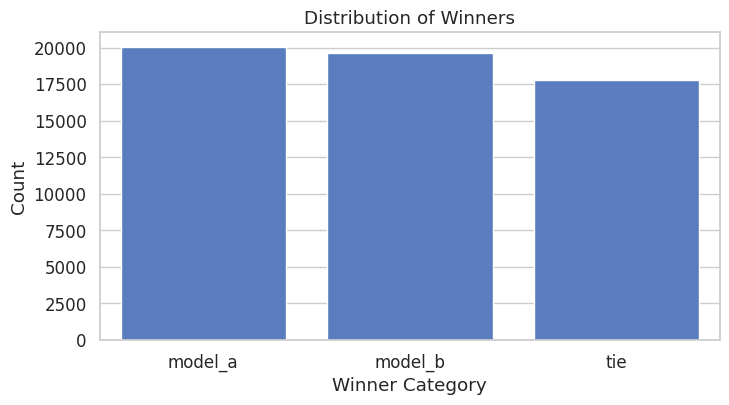

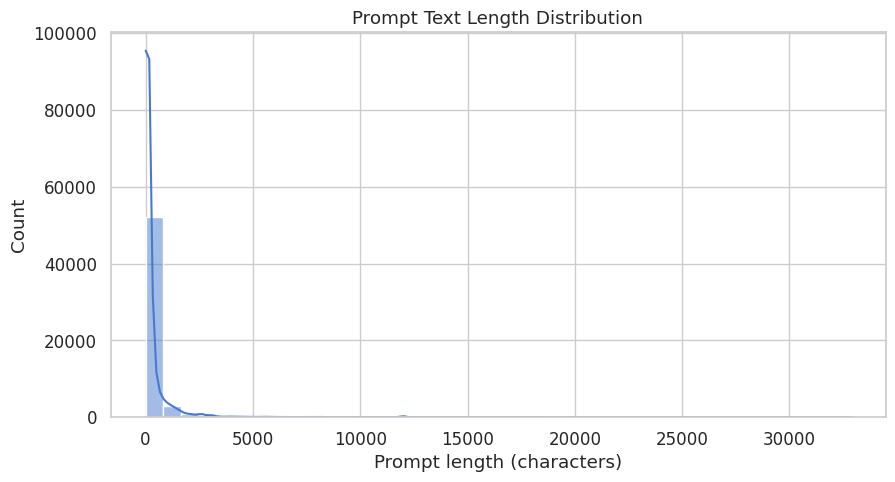

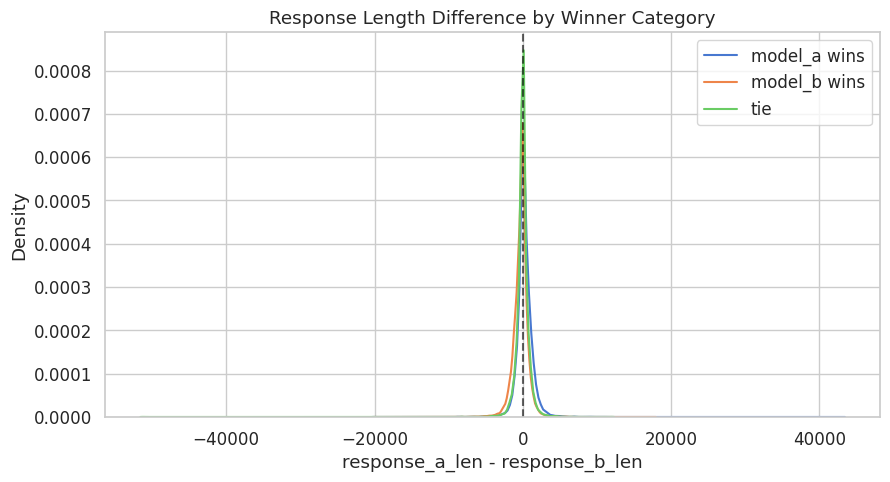

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid', palette='muted', font_scale=1.1)

plt.figure(figsize=(8, 4))
sns.countplot(x='winner', data=train, order=['model_a', 'model_b', 'tie'])
plt.title('Distribution of Winners')
plt.xlabel('Winner Category')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(10, 5))
sns.histplot(train['prompt_len'], bins=40, kde=True)
plt.title('Prompt Text Length Distribution')
plt.xlabel('Prompt length (characters)')
plt.show()

plt.figure(figsize=(10, 5))
sns.kdeplot(train.loc[train['winner'] == 'model_a', 'response_len_diff'], label='model_a wins')
sns.kdeplot(train.loc[train['winner'] == 'model_b', 'response_len_diff'], label='model_b wins')
sns.kdeplot(train.loc[train['winner'] == 'tie', 'response_len_diff'], label='tie')
plt.axvline(0, color='black', linestyle='--', alpha=0.6)
plt.title('Response Length Difference by Winner Category')
plt.xlabel('response_a_len - response_b_len')
plt.legend()
plt.show()

### Interpretation

- The winner distribution plot helps confirm whether the classes are reasonably balanced.
- Prompt lengths are broad, which means sequence models must handle both short and long user contexts.
- The response length difference plot shows whether the winning response is usually longer or shorter than its competitor, which can guide baseline feature engineering.

## 7. Model training and inference

This section trains a simple baseline classifier on text features derived from the prompt and both candidate responses.
The fitted model is then used to produce the probability predictions required for the submission.

In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import make_pipeline
from sklearn.metrics import log_loss

for frame in [train, test]:
    frame['prompt_list'] = frame['prompt'].apply(safe_parse_list)
    frame['response_a_list'] = frame['response_a'].apply(safe_parse_list)
    frame['response_b_list'] = frame['response_b'].apply(safe_parse_list)
    frame['prompt_text'] = frame['prompt_list'].apply(safe_join_list_as_text)
    frame['response_a_text'] = frame['response_a_list'].apply(safe_join_list_as_text)
    frame['response_b_text'] = frame['response_b_list'].apply(safe_join_list_as_text)
    frame['model_input'] = (
        frame['prompt_text']
        + " [A] "
        + frame['response_a_text']
        + " [B] "
        + frame['response_b_text']
    )

label_encoder = LabelEncoder()
train['winner_label'] = label_encoder.fit_transform(train['winner'])
X_train, X_val, y_train, y_val = train_test_split(
    train['model_input'],
    train['winner_label'],
    test_size=0.15,
    random_state=42,
    stratify=train['winner_label']
)
pipeline = make_pipeline(
    TfidfVectorizer(max_features=20000, ngram_range=(1, 2), min_df=2),
    LogisticRegression(
        max_iter=300,
        random_state=42,
        solver='lbfgs',
        C=2.0,
        class_weight='balanced'
    )
)
pipeline.fit(X_train, y_train)
val_probs = pipeline.predict_proba(X_val)
val_loss = log_loss(y_val, val_probs, labels=label_encoder.transform(label_encoder.classes_))
display(HTML(f'<h3>Baseline validation log loss: {val_loss:.4f}</h3>'))

def predict_submission_probabilities(test_df):
    if 'model_input' not in test_df.columns:
        test_df['prompt_list'] = test_df['prompt'].apply(safe_parse_list)
        test_df['response_a_list'] = test_df['response_a'].apply(safe_parse_list)
        test_df['response_b_list'] = test_df['response_b'].apply(safe_parse_list)
        test_df['prompt_text'] = test_df['prompt_list'].apply(safe_join_list_as_text)
        test_df['response_a_text'] = test_df['response_a_list'].apply(safe_join_list_as_text)
        test_df['response_b_text'] = test_df['response_b_list'].apply(safe_join_list_as_text)
        test_df['model_input'] = (
            test_df['prompt_text']
            + " [A] "
            + test_df['response_a_text']
            + " [B] "
            + test_df['response_b_text']
        )

    probs = pipeline.predict_proba(test_df['model_input'])
    class_names = label_encoder.classes_
    return pd.DataFrame(probs, columns=[f'winner_{name}' for name in class_names], index=test_df.index)


In [18]:
# Create the submission file using your model's predicted probabilities for each class
probabilities = predict_submission_probabilities(test)
submission = test[['id']].copy()
submission[['winner_model_a', 'winner_model_b', 'winner_tie']] = probabilities[['winner_model_a', 'winner_model_b', 'winner_tie']]

submission.to_csv('submission.csv', index=False)
display(HTML('<h3>Submission preview</h3>'))
display(submission.head(3))
print('submission saved at', Path('submission.csv').resolve())


,id,winner_model_a,winner_model_b,winner_tie
0,136060,0.149370,0.218779,0.631852
1,211333,0.527497,0.215572,0.256931
2,1233961,0.249955,0.587015,0.163030


submission saved at /kaggle/working/submission.csv
